In [1]:
from src import *

In [2]:
di_x, spade_x = [], []
di_y, spade_y = [], []

for duty in np.arange(0, 101, 2):
    for m in ('spade', 'di'):
        # try:
        #     c = LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d{duty}.npz')
        # except FileNotFoundError:
        #     pass
        c = LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d{duty}.npz')
        if m == 'spade':
            spade_x.append(duty)
            spade_y.append(c.frequency_estimates.var(ddof=1) * 1)

        if m == 'di':
            di_x.append(duty)
            di_y.append(c.frequency_estimates.var(ddof=1) * 1)

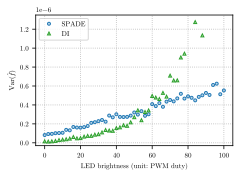

In [3]:
size = 9

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ax = plt.subplots(1, 1, figsize=(size / 2.54, size / 2.54 / 3 * 2))
ax.plot(spade_x, spade_y, linestyle='', linewidth=1,
        marker='o', markersize=3,
        markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

ax.plot(di_x, di_y, linestyle='', linewidth=1,
        marker='^', markersize=3,
        markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')

ax.legend(labels=['SPADE', 'DI'])
ax.grid(True, linestyle=':')


# axins = inset_axes(ax, width='20%', height='20%',loc='lower left',
#                    bbox_to_anchor=(0.05, 0.31, 1, 1),
#                    bbox_transform=ax.transAxes)



# axins.plot(spade_x[:6], spade_y[:6], color='#1f77b44d', linestyle='--', linewidth=1,
#            marker='o', markersize=2,
#            markeredgecolor='#1f77b4', markerfacecolor='#1f77b44d')

# axins.plot(di_x[:6], di_y[:6], color='#2ca02c4d', linestyle='--', linewidth=1,
#            marker='^', markersize=2,
#            markeredgecolor='#2ca02c', markerfacecolor='#2ca02c4d')


# mark_inset(ax, axins, loc1=3, loc2=4)

ax.set_xlabel('LED brightness (unit: PWM duty)')
ax.set_ylabel(r'${\rm Var}(\hat f)$')

ax.set_ylim(-3e-8, 1.35e-6)
plt.show()